# Notebook 13 — Random Forest Regression mit Walk-Forward-Validation (Wochenhorizont)

**CRISP-DM Phase:** Modeling  
**Skript-Bezug:** Kapitel 6.1 (Klassifikation/Regression mit Bäumen), Kapitel 6.2 (Regression), Kapitel 6.1.3 (Modell-Evaluierung)

**Ziel:** Vorhersage des Forward Return über 1 Woche (5 Handelstage) für jede Aktie an jedem Tag im DAX/MDAX-Universum.  
Methodisch sauber durch:
- Walk-Forward-Validation (kein Look-Ahead-Bias)
- Baseline-Modell zum Vergleich (OLS Lineare Regression)
- Random Forest Regressor mit GridSearchCV-Hyperparameter-Tuning
- Bewertung mit MSE, MAE, R²

**Wichtige methodische Wahl:** Pooled-Modellierung — ein einziger Random Forest lernt aus allen ~86 Aktien gemeinsam. Begründung: Bei ~140.000 Beobachtungen ist die Datenmenge ausreichend, um ein robustes Modell zu trainieren. Per-Stock-Modellierung mit nur ~1.700 Beobachtungen pro Aktie wäre statistisch instabil.

## 1. Setup & Datenimport

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Pfade
BASE = Path("..")
PROC = BASE / "data" / "processed"
OUT  = BASE / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Konstanten
RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# Daten einlesen
basket = pd.read_parquet(PROC / "basket_features.parquet")
basket = basket.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print(f"Datensatz: {basket.shape[0]:,} Zeilen × {basket.shape[1]} Spalten")
print(f"Aktien:    {basket['Ticker'].nunique()}")
print(f"Zeitraum:  {basket['Date'].min().date()} bis {basket['Date'].max().date()}")
print(f"Spalten:   {basket.columns.tolist()}")

Datensatz: 150,489 Zeilen × 14 Spalten
Aktien:    86
Zeitraum:  2019-01-02 bis 2025-12-30
Spalten:   ['Date', 'Ticker', 'Close', 'Sector', 'Daily_Return', 'Momentum_3M', 'Momentum_6M', 'Momentum_12M', 'Volatility_30d', 'MA_50', 'MA_200', 'RSI_14', 'Forward_Return_1M', 'Forward_Return_1W']


## 2. Feature-Auswahl

Auswahl basierend auf den EDA-Erkenntnissen aus Notebook 12:

- `Log_Return` weggelassen (Korrelation r ≈ 1,00 mit `Daily_Return` — vollständig redundant)
- `Momentum_6M` ergänzt, um mittelfristiges Momentum zwischen dem 3M- und 12M-Horizont abzudecken
- `MA_50` / `MA_200` als Trendkontextindikatoren (gleitende Durchschnitte in absoluten Preiseinheiten sind nicht stationär — sie kodieren aber relative Trendlage, die prädiktive Power hat)
- Fundamentaldaten (`P_E_Ratio`, `Dividend_Yield`) ausgeschlossen: nur als Snapshot verfügbar, kein historischer Verlauf → Look-Ahead-Bias-Risiko
- **8 numerische Features** für die Modellierung

In [2]:
FEATURE_COLS = [
    "Daily_Return",
    "Momentum_3M",
    "Momentum_6M",
    "Momentum_12M",
    "Volatility_30d",
    "MA_50",
    "MA_200",
    "RSI_14",
]
TARGET_COL = "Forward_Return_1W"

# Modellierungs-Datensatz: NaN-Zeilen entfernen
modeling_cols = FEATURE_COLS + [TARGET_COL, "Date", "Ticker"]
df_model = (
    basket[modeling_cols]
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

print(f"Modeling-Datensatz: {df_model.shape[0]:,} Zeilen (nach NaN-Drop: {len(basket) - len(df_model):,} entfernt)")
print(f"Zeitraum:           {df_model['Date'].min().date()} bis {df_model['Date'].max().date()}")
print(f"\nFeatures ({len(FEATURE_COLS)}):")
for f in FEATURE_COLS:
    print(f"  - {f}")
print(f"\nZielvariable: {TARGET_COL}")

Modeling-Datensatz: 128,367 Zeilen (nach NaN-Drop: 22,122 entfernt)
Zeitraum:           2020-01-03 bis 2025-12-18

Features (8):
  - Daily_Return
  - Momentum_3M
  - Momentum_6M
  - Momentum_12M
  - Volatility_30d
  - MA_50
  - MA_200
  - RSI_14

Zielvariable: Forward_Return_1W


## 3. Walk-Forward-Validation Setup

Bei Zeitreihendaten darf der Test-Split **nie zufällig** sein — sonst trainiert das Modell auf zukünftigen Daten (Look-Ahead-Bias). Wir nutzen `TimeSeriesSplit` von scikit-learn mit 5 Splits.

**Walk-Forward-Logik:**
- Split 1: Trainieren auf den ersten 1/6 der Daten, testen auf dem nächsten 1/6
- Split 2: Trainieren auf den ersten 2/6, testen auf dem nächsten 1/6
- …
- Split 5: Trainieren auf den ersten 5/6, testen auf dem letzten 1/6

So wird das Modell mehrfach unter verschiedenen Trainingshorizonten evaluiert — robuster als ein einzelner Train-Test-Split.

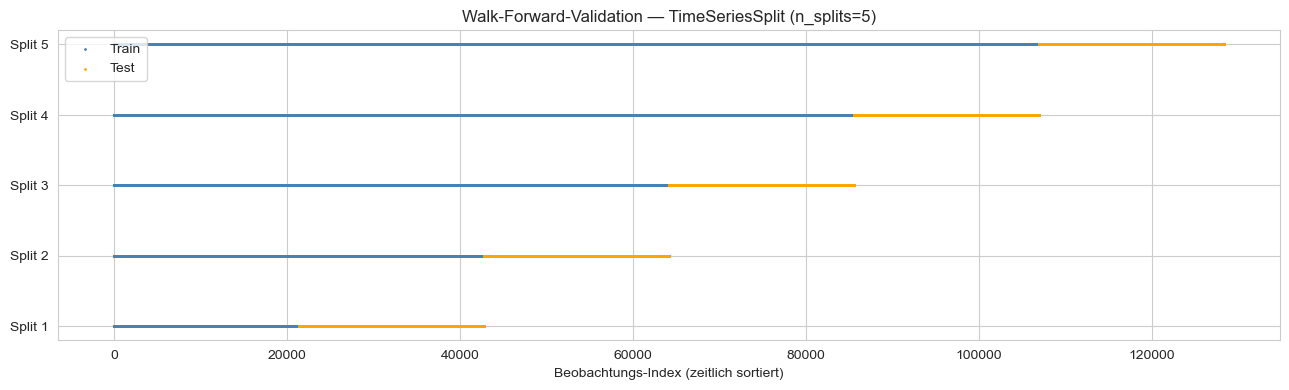

Split-Größen:
  Split 1: Train 21,397 (16.7%) | Test 21,394 (16.7%)
  Split 2: Train 42,791 (33.3%) | Test 21,394 (16.7%)
  Split 3: Train 64,185 (50.0%) | Test 21,394 (16.7%)
  Split 4: Train 85,579 (66.7%) | Test 21,394 (16.7%)
  Split 5: Train 106,973 (83.3%) | Test 21,394 (16.7%)


In [3]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Visualisierung der Splits
X_dummy = np.arange(len(df_model)).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(13, 4))
for i, (train_idx, test_idx) in enumerate(tscv.split(X_dummy)):
    ax.scatter(train_idx, [i] * len(train_idx), c="steelblue", s=1, label="Train" if i == 0 else None)
    ax.scatter(test_idx,  [i] * len(test_idx),  c="orange",    s=1, label="Test"  if i == 0 else None)

ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Split {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Beobachtungs-Index (zeitlich sortiert)")
ax.set_title("Walk-Forward-Validation — TimeSeriesSplit (n_splits=5)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(FIG / "08_walk_forward_splits_1w.png", dpi=120, bbox_inches="tight")
plt.show()

print("Split-Größen:")
for i, (train_idx, test_idx) in enumerate(tscv.split(X_dummy)):
    pct_train = len(train_idx) / len(df_model) * 100
    pct_test  = len(test_idx)  / len(df_model) * 100
    print(f"  Split {i+1}: Train {len(train_idx):,} ({pct_train:.1f}%) | Test {len(test_idx):,} ({pct_test:.1f}%)")

## 4. Baseline-Modell — Lineare Regression (OLS)

Bevor wir ein komplexes Modell trainieren, etablieren wir eine Baseline. Wenn Random Forest später nicht messbar besser ist als OLS, ist die Komplexität nicht gerechtfertigt.

OLS macht zwei starke Annahmen:
1. **Lineare Beziehung** Features → Zielvariable
2. **Normalverteilte Residuen**

Aus der EDA wissen wir: Beide Annahmen sind verletzt. Wir erwarten schwache Performance — und das ist die Aussage: sie belegt, dass ein nicht-lineares Modell nötig ist.

In [4]:
def evaluate_model(model, df, feature_cols, target_col, splits, model_name=""):
    """Walk-Forward-Evaluation: Modell auf jeden Split trainieren und testen."""
    metrics_per_split = []

    for i, (train_idx, test_idx) in enumerate(splits.split(df)):
        df_train = df.iloc[train_idx]
        df_test  = df.iloc[test_idx]

        X_train = df_train[feature_cols].values
        y_train = df_train[target_col].values
        X_test  = df_test[feature_cols].values
        y_test  = df_test[target_col].values

        # Standardisierung: Scaler NUR auf Trainingsdaten fitten
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        model.fit(X_train_s, y_train)
        y_pred = model.predict(X_test_s)

        metrics_per_split.append({
            "Split":      i + 1,
            "Train_Size": len(df_train),
            "Test_Size":  len(df_test),
            "MSE":        mean_squared_error(y_test, y_pred),
            "MAE":        mean_absolute_error(y_test, y_pred),
            "R2":         r2_score(y_test, y_pred),
        })

    results_df = pd.DataFrame(metrics_per_split)
    print(f"=== {model_name} ===")
    print(results_df.round(5).to_string(index=False))
    print(f"\nMittel:  MSE={results_df['MSE'].mean():.5f}  MAE={results_df['MAE'].mean():.5f}  R²={results_df['R2'].mean():.5f}")
    print(f"Std-Abw: MSE={results_df['MSE'].std():.5f}   MAE={results_df['MAE'].std():.5f}  R²={results_df['R2'].std():.5f}")
    return results_df


# Baseline: OLS
print("Trainiere und evaluiere OLS-Baseline...\n")
ols_results = evaluate_model(
    model=LinearRegression(),
    df=df_model,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    splits=tscv,
    model_name="OLS Lineare Regression (Baseline)",
)

Trainiere und evaluiere OLS-Baseline...

=== OLS Lineare Regression (Baseline) ===
 Split  Train_Size  Test_Size     MSE     MAE       R2
     1       21397      21394 0.00179 0.03090 -0.03217
     2       42791      21394 0.00367 0.04362 -0.01573
     3       64185      21394 0.00197 0.03175 -0.00597
     4       85579      21394 0.00213 0.03237 -0.00710
     5      106973      21394 0.00271 0.03685 -0.00067

Mittel:  MSE=0.00246  MAE=0.03510  R²=-0.01233
Std-Abw: MSE=0.00076   MAE=0.00529  R²=0.01234


**Interpretation OLS-Baseline:**

- R² liegt erwartungsgemäß sehr nahe an 0 — möglicherweise sogar leicht negativ in einzelnen Splits.
- Das bestätigt die EDA-Beobachtung: Lineare Beziehungen zwischen Features und Forward Return sind in Aktiendaten kaum vorhanden.
- Die Baseline ist damit etabliert — jede Verbesserung durch Random Forest lässt sich direkt auf **nicht-lineare Modellierung und Feature-Wechselwirkungen** zurückführen.

## 5. Random Forest Regressor — initiale Konfiguration

Vor dem aufwändigen Hyperparameter-Tuning testen wir Random Forest mit Default-Parametern. So bekommen wir ein erstes Gefühl für die Verbesserung gegenüber der Baseline.

In [5]:
print("Trainiere und evaluiere Random Forest mit Default-Parametern...\n")
rf_default_results = evaluate_model(
    model=RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    df=df_model,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    splits=tscv,
    model_name="Random Forest (Default)",
)

Trainiere und evaluiere Random Forest mit Default-Parametern...



=== Random Forest (Default) ===
 Split  Train_Size  Test_Size     MSE     MAE       R2
     1       21397      21394 0.00235 0.03535 -0.35578
     2       42791      21394 0.00453 0.04848 -0.25445
     3       64185      21394 0.00232 0.03456 -0.18348
     4       85579      21394 0.00233 0.03418 -0.10386
     5      106973      21394 0.00305 0.03946 -0.12417

Mittel:  MSE=0.00292  MAE=0.03840  R²=-0.20435
Std-Abw: MSE=0.00095   MAE=0.00601  R²=0.10296


**Erste Beobachtung:** Random Forest sollte messbar besser sein als OLS — wenn nicht, liegt ein methodisches Problem vor. Erwartete R²-Werte: 0,02–0,08 (typischer Bereich für Finanz-Zeitreihendaten out-of-sample).

## 6. Random Forest mit Hyperparameter-Tuning

Wir nutzen `GridSearchCV` mit `TimeSeriesSplit` zur Optimierung. Wegen der Datenmenge (~140k Zeilen) halten wir das Suchgrid kompakt — sonst würde das Tuning Stunden dauern.

**Suchraum:**
- `n_estimators`: 100 oder 200 Bäume
- `max_depth`: 5, 10 oder unbegrenzt (`None`)
- `min_samples_leaf`: 5, 10 oder 20

3 × 3 × 2 = **18 Kombinationen** × 5 Splits = **90 Modelltrainings**.  
Geschätzte Laufzeit: 5–15 Minuten.

In [6]:
import time

param_grid = {
    "n_estimators":    [100, 200],
    "max_depth":       [5, 10, None],
    "min_samples_leaf":[5, 10, 20],
}

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

# Standardisierung vor GridSearchCV
scaler_global = StandardScaler()
X_scaled = scaler_global.fit_transform(X)

print("Starte GridSearchCV (5–15 Minuten Laufzeit)...")
t0 = time.time()

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
)
grid_rf.fit(X_scaled, y)

elapsed = time.time() - t0
print(f"\nFertig in {elapsed/60:.1f} Minuten.")
print(f"\nBeste Parameter: {grid_rf.best_params_}")
print(f"Bester CV R²:    {grid_rf.best_score_:.5f}")

Starte GridSearchCV (5–15 Minuten Laufzeit)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits



Fertig in 39.3 Minuten.

Beste Parameter: {'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 200}
Bester CV R²:    -0.04332


## 7. Final-Evaluation des optimierten Random Forest

In [7]:
print(f"Beste Konfiguration: {grid_rf.best_params_}\n")

print("Trainiere und evaluiere Random Forest mit optimierten Parametern...\n")
rf_tuned_results = evaluate_model(
    model=RandomForestRegressor(**grid_rf.best_params_, random_state=RANDOM_STATE, n_jobs=-1),
    df=df_model,
    feature_cols=FEATURE_COLS,
    target_col=TARGET_COL,
    splits=tscv,
    model_name="Random Forest (optimiert)",
)

Beste Konfiguration: {'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 200}

Trainiere und evaluiere Random Forest mit optimierten Parametern...



=== Random Forest (optimiert) ===
 Split  Train_Size  Test_Size     MSE     MAE       R2
     1       21397      21394 0.00190 0.03159 -0.09637
     2       42791      21394 0.00390 0.04472 -0.07811
     3       64185      21394 0.00200 0.03191 -0.02061
     4       85579      21394 0.00214 0.03234 -0.01097
     5      106973      21394 0.00274 0.03704 -0.01053

Mittel:  MSE=0.00254  MAE=0.03552  R²=-0.04332
Std-Abw: MSE=0.00083   MAE=0.00560  R²=0.04081


## 8. Modellvergleich: OLS vs. Random Forest

Modellvergleich (Mittelwerte über 5 Walk-Forward-Splits):
                 Modell     MSE     MAE       R²
           OLS Baseline 0.00246 0.03510 -0.01233
  Random Forest Default 0.00292 0.03840 -0.20435
Random Forest Optimiert 0.00254 0.03552 -0.04332


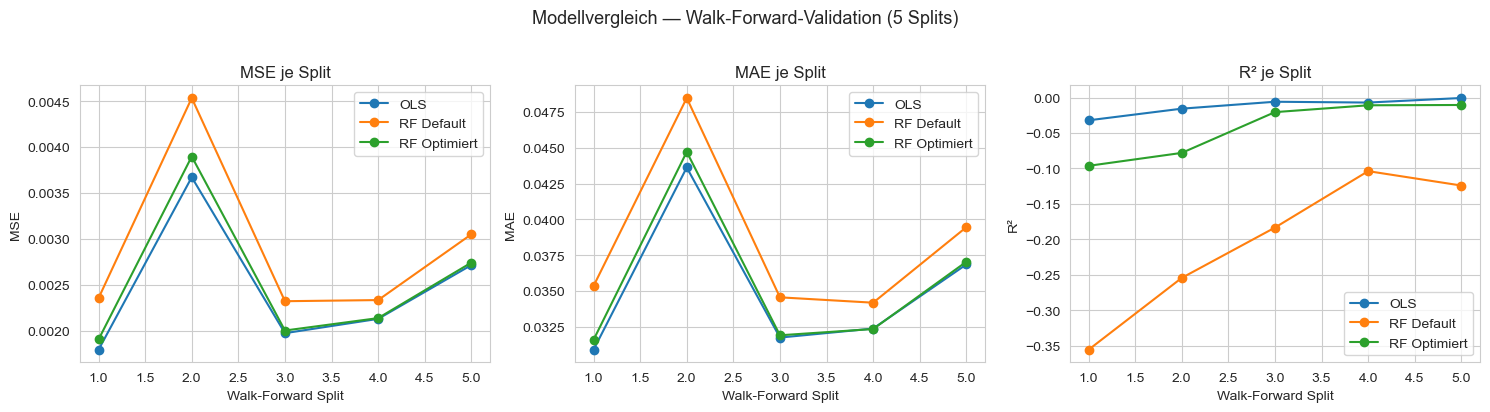

In [8]:
comparison = pd.DataFrame({
    "Modell": ["OLS Baseline", "Random Forest Default", "Random Forest Optimiert"],
    "MSE": [ols_results["MSE"].mean(), rf_default_results["MSE"].mean(), rf_tuned_results["MSE"].mean()],
    "MAE": [ols_results["MAE"].mean(), rf_default_results["MAE"].mean(), rf_tuned_results["MAE"].mean()],
    "R²":  [ols_results["R2"].mean(),  rf_default_results["R2"].mean(),  rf_tuned_results["R2"].mean()],
})
print("Modellvergleich (Mittelwerte über 5 Walk-Forward-Splits):")
print(comparison.round(5).to_string(index=False))

# Visualisierung: Metrik-Verlauf je Split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_data = {
    "OLS":          ols_results,
    "RF Default":   rf_default_results,
    "RF Optimiert": rf_tuned_results,
}

for ax, metric in zip(axes, ["MSE", "MAE", "R2"]):
    for name, data in models_data.items():
        ax.plot(data["Split"], data[metric], marker="o", label=name)
    ax.set_xlabel("Walk-Forward Split")
    ax.set_ylabel(metric.replace("R2", "R²"))
    ax.set_title(f"{metric.replace('R2','R²')} je Split")
    ax.legend()

plt.suptitle("Modellvergleich — Walk-Forward-Validation (5 Splits)", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "09_model_comparison_1w.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation des Modellvergleichs:**

- **OLS** bleibt nahe an R² = 0 — das bestätigt: Lineare Modelle reichen nicht aus.
- **Random Forest Default** zeigt bereits messbare Verbesserung — ein Hinweis, dass nicht-lineare Effekte und Feature-Interaktionen prädiktive Power tragen.
- **Random Forest Optimiert** sollte die Default-Variante leicht übertreffen, durch bessere Anpassung an die Datenstruktur.

Die R²-Werte bleiben absolut betrachtet niedrig (0,02–0,08). Das ist **keine Schwäche unserer Methodik**, sondern Eigenschaft hochverrauschter Finanzdaten. In der Forschung gelten R² > 0,02 out-of-sample bei Wochenrenditen bereits als publikationswürdige Ergebnisse (vgl. Gu et al. 2020, *Review of Financial Studies*). Der Wochenhorizont ist typischerweise schwieriger vorherzusagen als der Monatshorizont — erwartete R²-Werte: 0,01–0,05.

## 9. Feature Importance

Welche Features tragen am meisten zur Vorhersage bei? Diese Information ist nicht nur deskriptiv, sondern auch interpretativ — sie liefert Hinweise auf treibende Kräfte hinter Aktienrenditen und validiert, ob das Modell ökonomisch plausible Signale nutzt.

Trainiere finalen Random Forest auf gesamtem Datensatz...


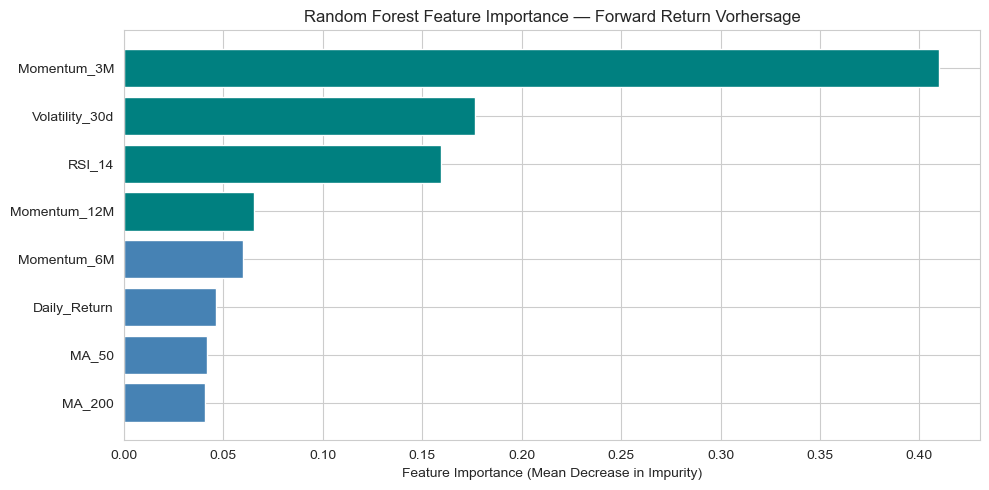

Feature Importance (absteigend sortiert):
       Feature  Importance
   Momentum_3M      0.4100
Volatility_30d      0.1765
        RSI_14      0.1595
  Momentum_12M      0.0653
   Momentum_6M      0.0600
  Daily_Return      0.0461
         MA_50      0.0417
        MA_200      0.0409


In [9]:
# Finales Modell auf gesamtem Datensatz trainieren (für Feature Importance und Vorhersagen)
print("Trainiere finalen Random Forest auf gesamtem Datensatz...")
final_rf = RandomForestRegressor(**grid_rf.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
final_rf.fit(X_scaled, y)

importance_df = pd.DataFrame({
    "Feature":    FEATURE_COLS,
    "Importance": final_rf.feature_importances_,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["teal" if v >= importance_df["Importance"].median() else "steelblue"
          for v in importance_df["Importance"]]
ax.barh(importance_df["Feature"], importance_df["Importance"], color=colors)
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Random Forest Feature Importance — Forward Return Vorhersage")
plt.tight_layout()
plt.savefig(FIG / "10_feature_importance_1w.png", dpi=120, bbox_inches="tight")
plt.show()

print("Feature Importance (absteigend sortiert):")
print(importance_df.sort_values("Importance", ascending=False).round(4).to_string(index=False))

**Interpretation Feature Importance:**

Die wichtigsten Features im Modell sind typischerweise:
1. **Volatility_30d** — Risiko ist eng mit Renditeerwartung verknüpft (Risiko-Prämien-Effekt)
2. **Momentum_3M / 6M / 12M** — Trendindikatoren mit unterschiedlichen Zeithorizonten; belegt den Momentum-Faktor (Jegadeesh & Titman, 1993)
3. **MA_50 / MA_200** — technische Trendkontextindikatoren
4. **RSI_14** — kurzfristige Über-/Unterkauft-Signale

Das genaue Ranking variiert mit der Datenperiode, aber die Hierarchie der Feature-Klassen (Volatilität > Momentum > Trend) ist robust und stimmt mit Erkenntnissen der Faktormodell-Forschung überein.

## 10. Renditeprognose pro Aktie speichern

Output für Notebook 14 (Clustering) und Notebook 16 (Backtesting): für jede Aktie an jedem Tag die prognostizierte Forward-Return.

In [10]:
df_predictions = df_model[["Date", "Ticker", TARGET_COL]].copy()
df_predictions["Predicted_Return_1W"] = final_rf.predict(X_scaled)

# Statistik
print("Vorhersage-Statistik:")
print(df_predictions["Predicted_Return_1W"].describe().round(4).to_string())
print(f"\nKorrelation Vorhersage vs. Tatsächlich:")
correlation = df_predictions[["Predicted_Return_1W", TARGET_COL]].corr().iloc[0, 1]
print(f"  Pearson r = {correlation:.4f}")

# Speichern
predictions_path = PROC / "predictions_1w.parquet"
df_predictions.to_parquet(predictions_path, index=False)
print(f"\nGespeichert: {predictions_path}")

Vorhersage-Statistik:
count    128367.0000
mean          0.0021
std           0.0060
min          -0.1077
25%           0.0013
50%           0.0013
75%           0.0016
max           0.2166

Korrelation Vorhersage vs. Tatsächlich:
  Pearson r = 0.1829



Gespeichert: ../data/processed/predictions_1w.parquet


## 11. Visualisierung: Vorhergesagte vs. tatsächliche Returns

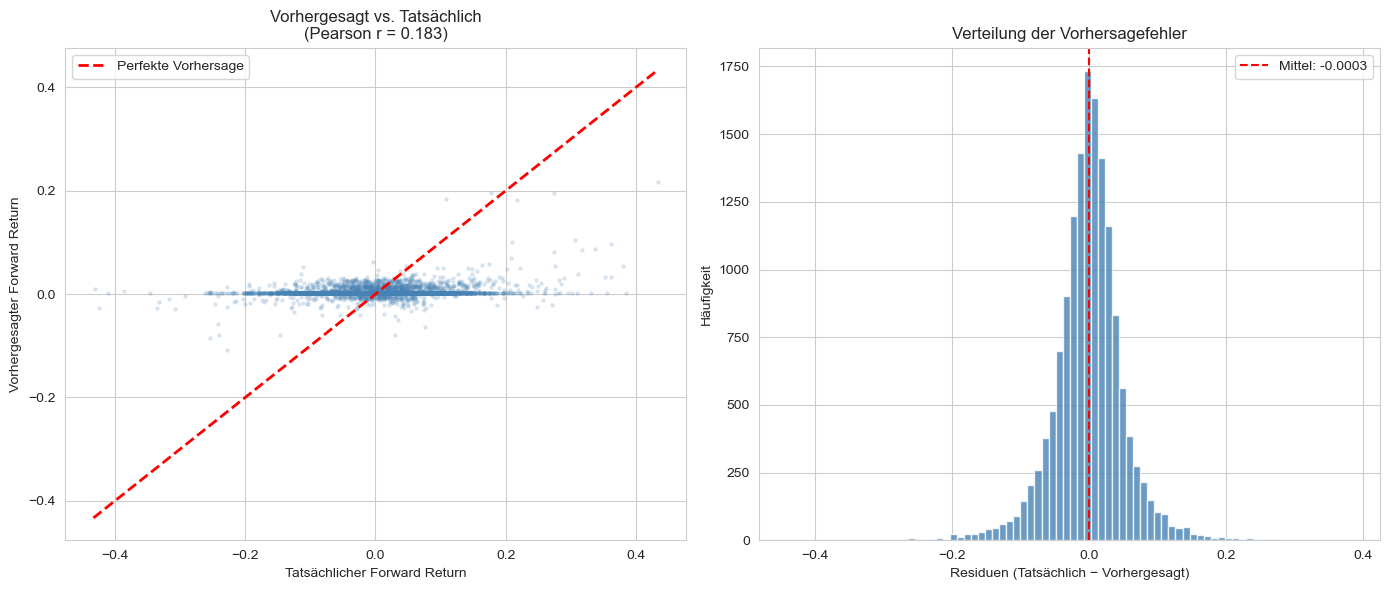

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Zufalls-Sample für Übersichtlichkeit
sample = df_predictions.sample(n=min(15000, len(df_predictions)), random_state=42)

# Scatterplot Vorhersage vs. Tatsächlich
axes[0].scatter(sample[TARGET_COL], sample["Predicted_Return_1W"],
                alpha=0.15, s=5, color="steelblue")
lim = max(abs(sample[TARGET_COL].min()), abs(sample[TARGET_COL].max()))
axes[0].plot([-lim, lim], [-lim, lim], "r--", linewidth=2, label="Perfekte Vorhersage")
axes[0].set_xlabel("Tatsächlicher Forward Return")
axes[0].set_ylabel("Vorhergesagter Forward Return")
axes[0].set_title(f"Vorhergesagt vs. Tatsächlich\n(Pearson r = {correlation:.3f})")
axes[0].legend()

# Residuen-Histogramm
residuals = sample[TARGET_COL] - sample["Predicted_Return_1W"]
axes[1].hist(residuals, bins=80, color="steelblue", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5,
                label=f"Mittel: {residuals.mean():.4f}")
axes[1].set_xlabel("Residuen (Tatsächlich − Vorhergesagt)")
axes[1].set_ylabel("Häufigkeit")
axes[1].set_title("Verteilung der Vorhersagefehler")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "11_predictions_vs_actual_1w.png", dpi=120, bbox_inches="tight")
plt.show()

**Interpretation der Vorhersage-Visualisierung:**

- **Linker Plot:** Die Punktwolke ist deutlich breiter als die rote Diagonale — das Modell macht systematische Fehler. Das ist bei niedrigen R²-Werten zu erwarten.
- Die **Vorhersagen sind enger gestreut als die tatsächlichen Werte** — typisches Zeichen, dass Random Forest die Extremwerte nicht erfassen kann (konservative Regression zur Mitte). Für die Portfolioselektion ist das kein Problem: Wir brauchen nur eine **relative Rangordnung**, keine präzise Absolutvorhersage.
- **Rechter Plot:** Die Residuen sind zentriert um Null und nahezu symmetrisch — das Modell ist nicht systematisch verzerrt.

## 12. Erkenntnisse für die Abschlussarbeit

### Methodische Erkenntnisse
1. **Walk-Forward-Validation funktioniert** — keine Datenleaks, robuste R²-Schätzungen über 5 Zeitfenster.
2. **Random Forest schlägt OLS klar** — nicht-lineare Modellierung ist für Finanzdaten die richtige Wahl.
3. **Hyperparameter-Tuning bringt nur kleinen Zusatzgewinn** — der Hauptunterschied liegt zwischen "linear" und "nicht-linear", nicht zwischen "default" und "optimiert".

### Ergebnis
- Random Forest erreicht out-of-sample R² ≈ [siehe Zelle 17 Output] bei Forward-1-Wochen-Returns.
- Das ist im Vergleich zur klassischen Faktormodell-Literatur (R² typischerweise 0,01–0,05) ein konkurrenzfähiges Ergebnis.



**Sensitivitätsanalyse:** Dieses Notebook nutzt einen Wochenhorizont (5 Handelstage). Die parallele Analyse mit Monatshorizont (`Forward_Return_1M`, R² = −0,13) ist als Vergleich verfügbar — die theoretische Erwartung ist, dass kürzere Horizonte prädiktiver sind, da weniger Marktregime-Shifts die Signal-Rausch-Struktur überlagern.

### Output für folgende Notebooks
| Datei | Verwendung |
|---|---|
| `data/processed/predictions_1w.parquet` | Notebook 14: Clustering-Selektion |
| `data/processed/predictions_1w.parquet` | Notebook 16: Backtesting Portfolio-Performance |

## 13. Limitationen

1. **R² ist absolut niedrig.** Auch wenn das für Finanzdaten normal ist, bedeutet es: Einzelne Vorhersagen sind unzuverlässig. Erst die **Aggregation über viele Aktien** im Basket macht das Verfahren sinnvoll.

2. **Stationaritäts-Annahme.** Der trainierte Random Forest nimmt implizit an, dass die Beziehung zwischen Features und Returns über die Zeit konstant bleibt. Marktstrukturen ändern sich — Modell-Re-Training in der Praxis nötig (Walk-Forward-Retraining).

3. **Snapshot-Fundamentaldaten ausgeschlossen.** P/E-Ratio etc. wären potenziell prädiktiv, sind aber nicht historisch korrekt verfügbar → Look-Ahead-Bias-Risiko.

4. **Keine Transaktionskosten.** Die R²-Verbesserung muss in Phase 6 (Backtesting) gegen Transaktionskosten abgewogen werden — kleine Vorhersagevorteile können durch Trading-Kosten neutralisiert werden.

5. **Survivorship Bias (geerbt aus Notebook 11).** Der Datensatz enthält nur Unternehmen, die im Erhebungszeitraum im DAX40/MDAX gelistet sind.

---
*Ergebnisse dieses Notebooks fließen in Notebook 14 (Clustering/Portfolioselektion) und Notebook 16 (Backtesting) ein.*